In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (250744, 50)


,transaction_id,user_id,device_id,merchant_id,session_id,txn_time,txn_amount,txn_currency,txn_hour,txn_day_of_week,...,avg_txn_amount_90d,dormant_account_flag,new_payee_added_24h,email_change_7d,phone_change_7d,geo_distance_last_login,impossible_travel_flag,login_hour_deviation,session_duration_zscore,fraud_label
0,1,16795,8512,3450,93177,26-04-2024 9:41,75.985614,USD,9,4,...,14.933552,0,0,0,0,1.460731,0,4.129832,-1.463200,0
1,2,1860,4155,3552,461632,21-01-2024 6:24,22.339063,CAD,6,6,...,9.163966,0,0,0,0,81.059175,0,0.534457,-0.823666,0
2,3,39158,12806,3480,261998,05-01-2024 13:16,113.278392,USD,13,4,...,229.594905,0,0,0,0,65.769144,0,-0.484853,0.443232,0
3,4,12284,3770,3273,266224,14-05-2024 23:53,45.821144,CAD,23,1,...,237.550036,0,0,0,0,44.559035,0,-1.228798,2.307250,0
4,5,7265,11772,3353,419057,20-02-2024 1:37,120.520888,CAD,1,1,...,15.370694,0,1,0,0,85.293193,0,3.144927,-1.884058,0


In [6]:
y = df['fraud_label']
X = df.drop(columns=['fraud_label'])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
   X, y,
   test_size=0.2,
   stratify=y,
   random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (200595, 49)
Test shape: (50149, 49)


In [ ]:
preprocessor = joblib.load("../models/preprocessor.pkl")


In [10]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)


Processed train shape: (200595, 139825)


In [11]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(X_train_processed, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [13]:
joblib.dump(model, "../models/logistic_model.pkl")


['../models/logistic_model.pkl']

In [14]:
y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:, 1]

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.93      0.94     47378
           1       0.11      0.16      0.13      2771

    accuracy                           0.88     50149
   macro avg       0.53      0.54      0.53     50149
weighted avg       0.90      0.88      0.89     50149



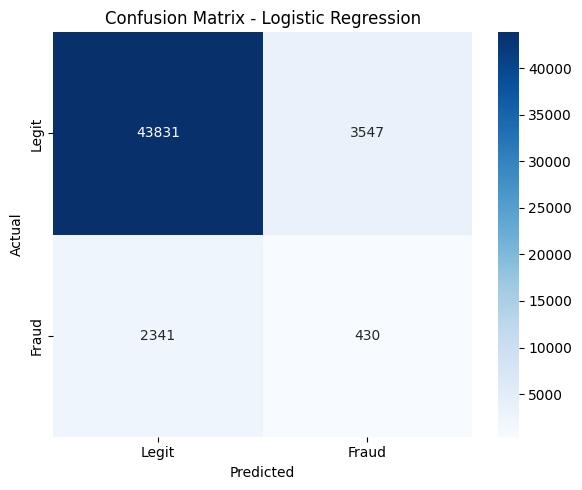

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
           annot=True,
           fmt="d",
           cmap="Blues",
           xticklabels=["Legit", "Fraud"],
           yticklabels=["Legit", "Fraud"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()
plt.savefig("../reports/figures/logistic_confusion_matrix.png")

plt.show()


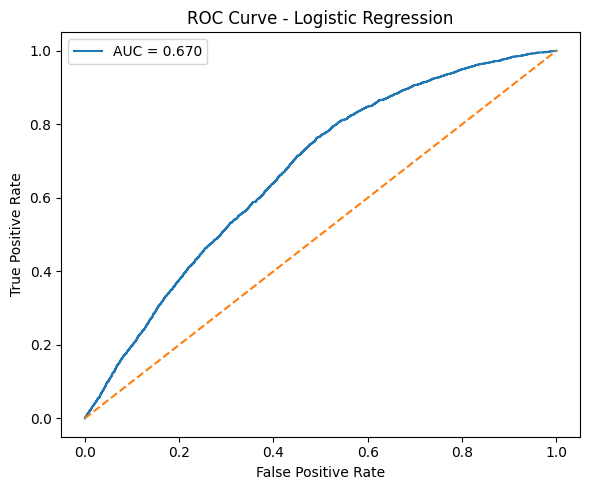

ROC-AUC: 0.6699465400461249


In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.tight_layout()
plt.savefig("../reports/figures/logistic_roc_curve.png")

plt.show()

print("ROC-AUC:", roc_auc)
